In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# Exploratory Data Analysis (EDA)

from sklearn.preprocessing import StandardScaler

## Task info

Your task

Implement a machine learning system that predicts being diagnosed with heart disease

1) Apply EDA to extract useful insights
2) Build your preprocessing pipeline consisting of scaling, label-encoding, one-hot encoding
3) Try the 3 models we covered logistic regression, svm & knn
 
Evaluate your model accuracy, precesion, recall, ......

Kindly deploy on a streamlit app

In [3]:
os.listdir('data/raw/')

['Heart-Disease-Patients-Records.csv']

In [4]:
df = pd.read_csv('data/raw/Heart-Disease-Patients-Records.csv')

# Data info
- -EDA-1 = 
- A /data/raw/Exam_Score_Prediction.csv 
- B data/feature eng data/feature_eng_data.csv

- -Pre-processed-2
- A data/feature eng data/feature_eng_data.csv
- B data/preprocessed data/pre-processed_data.csv

- -Machine-learning-3 = 
- A /data/preprocessed data/pre-processed_data.csv
- B /artifacts/svm_pipeline.pkl

In [5]:
df.columns

Index(['age', 'sex', 'chest_pain_type', 'resisting_blood_pressure',
       'cholesterol_level', 'fasting_blood_sugar', 'rest_ecg',
       'max_heart_rate_achieved', 'exercise_induced_angina', 'st_depression',
       'st_slope', 'num_major_vessels', 'thalassemia', 'diagnosis'],
      dtype='object')

In [6]:
duplicated = df[df.duplicated()]
# Leer weil alles bereinigt ist.
duplicated

,age,sex,chest_pain_type,resisting_blood_pressure,cholesterol_level,fasting_blood_sugar,rest_ecg,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,diagnosis
15,34,female,atypical angina,118,210,lower than 120mg/ml,ST-T wave abnormality,192,no,0.7,downsloping,0,fixed defect,Un-Diagnosed
31,50,female,atypical angina,120,244,lower than 120mg/ml,ST-T wave abnormality,162,no,1.1,downsloping,0,fixed defect,Un-Diagnosed
43,46,male,typical angina,120,249,lower than 120mg/ml,normal,144,no,0.8,downsloping,0,reversable defect,Diagnosed
55,55,male,typical angina,140,217,lower than 120mg/ml,ST-T wave abnormality,111,yes,5.6,upsloping,0,reversable defect,Diagnosed
61,66,female,non-anginal pain,146,278,lower than 120mg/ml,normal,152,no,0.0,flat,1,fixed defect,Un-Diagnosed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,male,atypical angina,140,221,lower than 120mg/ml,ST-T wave abnormality,164,yes,0.0,downsloping,0,fixed defect,Un-Diagnosed
1021,60,male,typical angina,125,258,lower than 120mg/ml,normal,141,yes,2.8,flat,1,reversable defect,Diagnosed
1022,47,male,typical angina,110,275,lower than 120mg/ml,normal,118,yes,1.0,flat,1,fixed defect,Diagnosed
1023,50,female,typical angina,110,254,lower than 120mg/ml,normal,159,no,0.0,downsloping,0,fixed defect,Un-Diagnosed


In [7]:
df.shape

(1025, 14)

In [8]:
df.duplicated().sum()

np.int64(723)

In [9]:
#df.drop_duplicates(inplace= True)

In [10]:
df.duplicated().sum()

np.int64(723)

### Angenohmen gibt es duplicated: so prüfen

In [11]:
duplicated = df[df.duplicated()]
# Leer weil alles bereinigt ist.
duplicated

,age,sex,chest_pain_type,resisting_blood_pressure,cholesterol_level,fasting_blood_sugar,rest_ecg,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,diagnosis
15,34,female,atypical angina,118,210,lower than 120mg/ml,ST-T wave abnormality,192,no,0.7,downsloping,0,fixed defect,Un-Diagnosed
31,50,female,atypical angina,120,244,lower than 120mg/ml,ST-T wave abnormality,162,no,1.1,downsloping,0,fixed defect,Un-Diagnosed
43,46,male,typical angina,120,249,lower than 120mg/ml,normal,144,no,0.8,downsloping,0,reversable defect,Diagnosed
55,55,male,typical angina,140,217,lower than 120mg/ml,ST-T wave abnormality,111,yes,5.6,upsloping,0,reversable defect,Diagnosed
61,66,female,non-anginal pain,146,278,lower than 120mg/ml,normal,152,no,0.0,flat,1,fixed defect,Un-Diagnosed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,male,atypical angina,140,221,lower than 120mg/ml,ST-T wave abnormality,164,yes,0.0,downsloping,0,fixed defect,Un-Diagnosed
1021,60,male,typical angina,125,258,lower than 120mg/ml,normal,141,yes,2.8,flat,1,reversable defect,Diagnosed
1022,47,male,typical angina,110,275,lower than 120mg/ml,normal,118,yes,1.0,flat,1,fixed defect,Diagnosed
1023,50,female,typical angina,110,254,lower than 120mg/ml,normal,159,no,0.0,downsloping,0,fixed defect,Un-Diagnosed


In [12]:
# Zeigt alle Zeilen an, die irgendwo eine exakte Kopie haben
alle_doppelten = df[df.duplicated(keep=False)].sort_values(by=list(df.columns))
print(alle_doppelten)
# Leer weil alles bereinigt ist.

     age     sex   chest_pain_type  resisting_blood_pressure  \
60    29    male   atypical angina                       130   
64    29    male   atypical angina                       130   
118   29    male   atypical angina                       130   
668   29    male   atypical angina                       130   
12    34  female   atypical angina                       118   
..   ...     ...               ...                       ...   
535   76  female  non-anginal pain                       140   
965   76  female  non-anginal pain                       140   
160   77    male    typical angina                       125   
162   77    male    typical angina                       125   
387   77    male    typical angina                       125   

     cholesterol_level  fasting_blood_sugar                      rest_ecg  \
60                 204  lower than 120mg/ml                        normal   
64                 204  lower than 120mg/ml                        normal   


In [13]:
df.isna().sum()

age                         0
sex                         0
chest_pain_type             0
resisting_blood_pressure    0
cholesterol_level           0
fasting_blood_sugar         0
rest_ecg                    0
max_heart_rate_achieved     0
exercise_induced_angina     0
st_depression               0
st_slope                    0
num_major_vessels           0
thalassemia                 0
diagnosis                   0
dtype: int64

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1025 non-null   int64  
 1   sex                       1025 non-null   object 
 2   chest_pain_type           1025 non-null   object 
 3   resisting_blood_pressure  1025 non-null   int64  
 4   cholesterol_level         1025 non-null   int64  
 5   fasting_blood_sugar       1025 non-null   object 
 6   rest_ecg                  1025 non-null   object 
 7   max_heart_rate_achieved   1025 non-null   int64  
 8   exercise_induced_angina   1025 non-null   object 
 9   st_depression             1025 non-null   float64
 10  st_slope                  1025 non-null   object 
 11  num_major_vessels         1025 non-null   int64  
 12  thalassemia               1025 non-null   object 
 13  diagnosis                 1025 non-null   object 
dtypes: float

## Suche für Label Encoding

### Hier ist null falsch

In [15]:
df["thalassemia"].unique()

# Null '0' ist falsch muss bereinigt werden

array(['reversable defect', 'fixed defect', 'normal', '0'], dtype=object)

In [16]:
df["thalassemia"].value_counts()

thalassemia
fixed defect         544
reversable defect    410
normal                64
0                      7
Name: count, dtype: int64

## Datenbereinigung:

- Fall 1 (ID 14): Der 52-jährige Mann
Status: "Diagnosed" (Herzkrankheit liegt vor).
Meine Entscheidung: reversable defect.

- Fall 2 (ID 319): Die 53-jährige Frau
Status: "Un-Diagnosed" (Gesund).
Meine Entscheidung: normal

In [17]:
df [ df["thalassemia"] == '0']

,age,sex,chest_pain_type,resisting_blood_pressure,cholesterol_level,fasting_blood_sugar,rest_ecg,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,diagnosis
14,52,male,typical angina,128,204,higher than 120mg/ml,ST-T wave abnormality,156,yes,1.0,flat,0,0,Diagnosed
319,53,female,non-anginal pain,128,216,lower than 120mg/ml,normal,115,no,0.0,downsloping,0,0,Un-Diagnosed
329,53,female,non-anginal pain,128,216,lower than 120mg/ml,normal,115,no,0.0,downsloping,0,0,Un-Diagnosed
359,53,female,non-anginal pain,128,216,lower than 120mg/ml,normal,115,no,0.0,downsloping,0,0,Un-Diagnosed
686,52,male,typical angina,128,204,higher than 120mg/ml,ST-T wave abnormality,156,yes,1.0,flat,0,0,Diagnosed
734,52,male,typical angina,128,204,higher than 120mg/ml,ST-T wave abnormality,156,yes,1.0,flat,0,0,Diagnosed
893,52,male,typical angina,128,204,higher than 120mg/ml,ST-T wave abnormality,156,yes,1.0,flat,0,0,Diagnosed


In [18]:
df.loc[[14,686,734,893], 'thalassemia'] = 'fixed defect'
df.loc[[14,686,734,893]]

,age,sex,chest_pain_type,resisting_blood_pressure,cholesterol_level,fasting_blood_sugar,rest_ecg,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,diagnosis
14,52,male,typical angina,128,204,higher than 120mg/ml,ST-T wave abnormality,156,yes,1.0,flat,0,fixed defect,Diagnosed
686,52,male,typical angina,128,204,higher than 120mg/ml,ST-T wave abnormality,156,yes,1.0,flat,0,fixed defect,Diagnosed
734,52,male,typical angina,128,204,higher than 120mg/ml,ST-T wave abnormality,156,yes,1.0,flat,0,fixed defect,Diagnosed
893,52,male,typical angina,128,204,higher than 120mg/ml,ST-T wave abnormality,156,yes,1.0,flat,0,fixed defect,Diagnosed


In [19]:
print(df.loc[[14,686,734,893], "thalassemia"])

14     fixed defect
686    fixed defect
734    fixed defect
893    fixed defect
Name: thalassemia, dtype: object


In [20]:
df.loc[[319,329,359], 'thalassemia'] = 'reversable defect'

In [21]:
df.loc[[319,329,359]]

,age,sex,chest_pain_type,resisting_blood_pressure,cholesterol_level,fasting_blood_sugar,rest_ecg,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,diagnosis
319,53,female,non-anginal pain,128,216,lower than 120mg/ml,normal,115,no,0.0,downsloping,0,reversable defect,Un-Diagnosed
329,53,female,non-anginal pain,128,216,lower than 120mg/ml,normal,115,no,0.0,downsloping,0,reversable defect,Un-Diagnosed
359,53,female,non-anginal pain,128,216,lower than 120mg/ml,normal,115,no,0.0,downsloping,0,reversable defect,Un-Diagnosed


In [22]:
df["thalassemia"].unique()

# Label eccoding

array(['reversable defect', 'fixed defect', 'normal'], dtype=object)

In [23]:
df.sample(3)

,age,sex,chest_pain_type,resisting_blood_pressure,cholesterol_level,fasting_blood_sugar,rest_ecg,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,diagnosis
269,71,female,non-anginal pain,110,265,higher than 120mg/ml,normal,130,no,0.0,downsloping,1,fixed defect,Un-Diagnosed
757,66,male,typical angina,160,228,lower than 120mg/ml,normal,138,no,2.3,downsloping,0,normal,Un-Diagnosed
417,52,male,non-anginal pain,138,223,lower than 120mg/ml,ST-T wave abnormality,169,no,0.0,downsloping,4,fixed defect,Un-Diagnosed


# Visualation

In [24]:
numerical_columns = df.select_dtypes(exclude=['object']).columns
numerical_columns

Index(['age', 'resisting_blood_pressure', 'cholesterol_level',
       'max_heart_rate_achieved', 'st_depression', 'num_major_vessels'],
      dtype='object')

In [25]:
px.histogram(df, x =numerical_columns, template = 'simple_white', 
             title = 'A quick inspection of Numerical columns distribution',
              marginal = 'box' , barmode='group', nbins=10,)# barmode='group'

# Category Columns

In [26]:
category_columns = df.select_dtypes(include=['O']).columns
category_columns

Index(['sex', 'chest_pain_type', 'fasting_blood_sugar', 'rest_ecg',
       'exercise_induced_angina', 'st_slope', 'thalassemia', 'diagnosis'],
      dtype='object')

In [27]:
px.histogram( df, x= category_columns, barmode='group', nbins=1 )

# Data visualation
- Distribution & oulieres
## Skewness

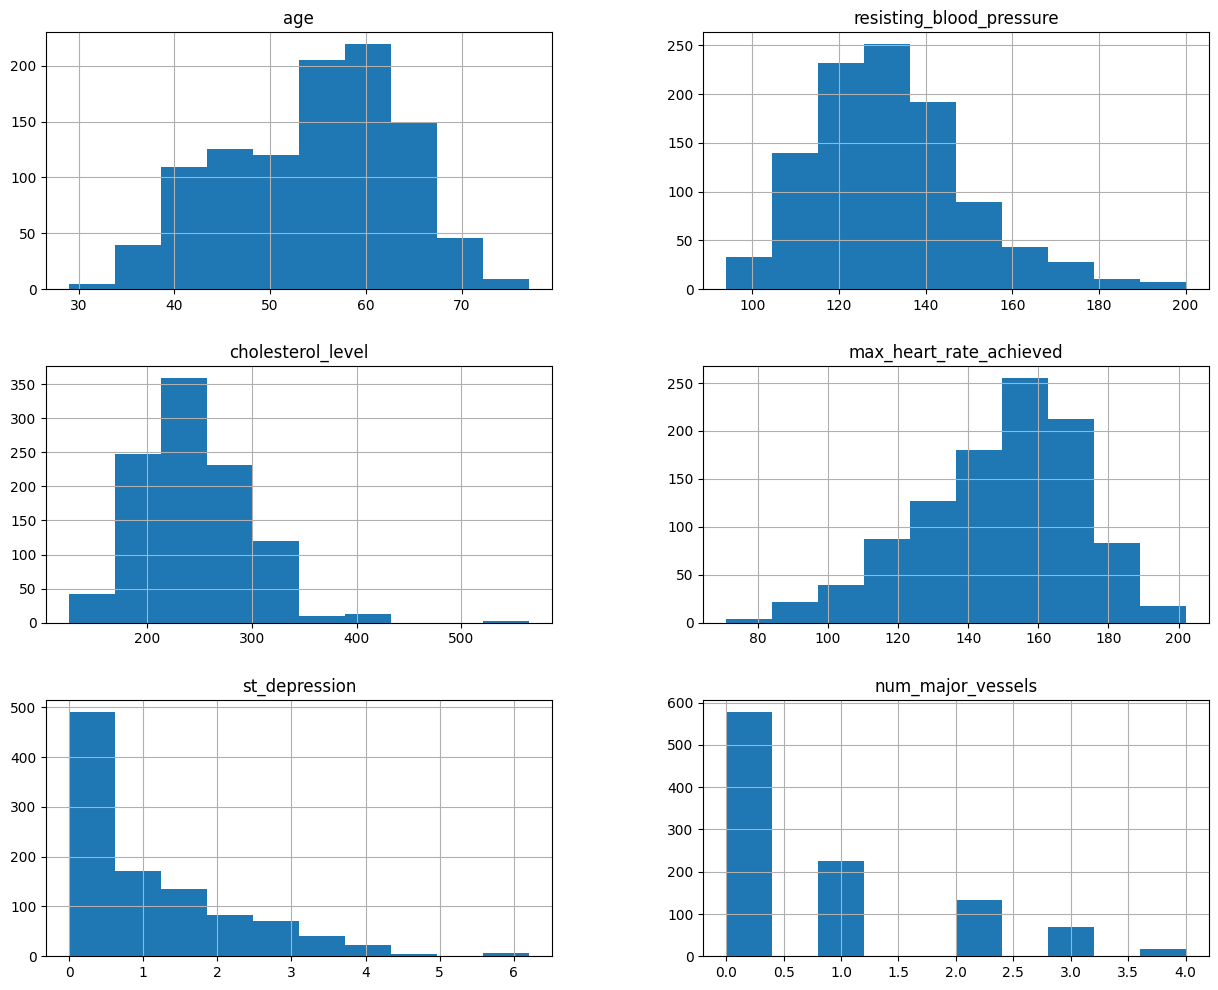

In [28]:
df.hist( figsize= (15, 12));

# SME = Subject Matter Expert

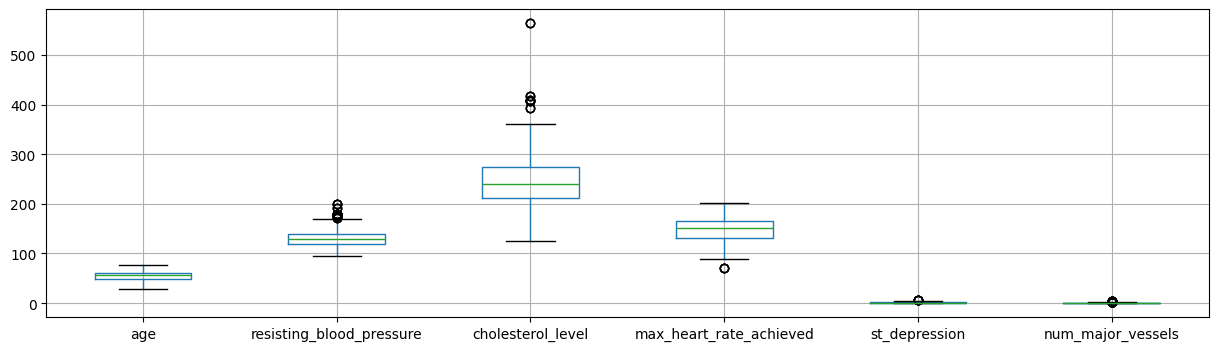

In [29]:
df.boxplot( figsize= ( 15, 4))
plt.xticks( rotation = 0);

In [30]:
df.describe()

,age,resisting_blood_pressure,cholesterol_level,max_heart_rate_achieved,st_depression,num_major_vessels
count,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000
mean,54.434146,131.611707,246.00000,149.114146,1.071512,0.754146
std,9.072290,17.516718,51.59251,23.005724,1.175053,1.030798
min,29.000000,94.000000,126.00000,71.000000,0.000000,0.000000
25%,48.000000,120.000000,211.00000,132.000000,0.000000,0.000000
50%,56.000000,130.000000,240.00000,152.000000,0.800000,0.000000
75%,61.000000,140.000000,275.00000,166.000000,1.800000,1.000000
max,77.000000,200.000000,564.00000,202.000000,6.200000,4.000000


In [31]:
df.isna().sum()

age                         0
sex                         0
chest_pain_type             0
resisting_blood_pressure    0
cholesterol_level           0
fasting_blood_sugar         0
rest_ecg                    0
max_heart_rate_achieved     0
exercise_induced_angina     0
st_depression               0
st_slope                    0
num_major_vessels           0
thalassemia                 0
diagnosis                   0
dtype: int64

In [32]:
os.listdir('data/feature eng data')

['feature_eng_data.csv']

In [33]:
df.to_csv('data/feature eng data/feature_eng_data.csv', index= False)